In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/afrojkhan/Downloads/Online_Retail.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df=df.drop(columns=["CustomerID"])

In [7]:
df_clean=df[df["UnitPrice"]>0]

In [8]:
df_clean=df_clean[df_clean['Quantity']>0]

In [9]:
df_clean.shape

(530104, 7)

In [10]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
Country        0
dtype: int64

In [11]:
df_clean.sample(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
259040,559684,20712,JUMBO BAG WOODLAND ANIMALS,10,7/11/11 15:05,2.08,United Kingdom
235310,557636,21201,TROPICAL HONEYCOMB PAPER GARLAND,2,6/21/11 15:41,2.55,United Kingdom
121619,546774,47566B,TEA TIME PARTY BUNTING,2,3/16/11 15:45,4.95,United Kingdom
125841,547062,85040B,SET/4 BLUE FLOWER CANDLES IN BOWL,1,3/20/11 13:28,1.65,United Kingdom
72972,542275,22227,HANGING HEART MIRROR DECORATION,24,1/27/11 10:18,0.65,United Kingdom
415460,572540,85099B,JUMBO BAG RED RETROSPOT,20,10/24/11 16:17,4.13,United Kingdom
303103,563508,23168,CLASSIC CAFE SUGAR DISPENSER,12,8/17/11 10:27,1.25,United Kingdom
59266,541280,17012A,ORIGAMI VANILLA INCENSE/CANDLE SET,6,1/17/11 11:57,2.55,United Kingdom
354335,567875,21485,RETROSPOT HEART HOT WATER BOTTLE,2,9/22/11 14:29,4.95,United Kingdom
450965,575177,23199,JUMBO BAG APPLES,1,11/8/11 18:41,4.13,United Kingdom


In [12]:
non_digits=df_clean[~df_clean['InvoiceNo'].astype(str).str.isdigit()]
non_digits

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
299982,A563185,B,Adjust bad debt,1,8/12/11 14:50,11062.06,United Kingdom


In [13]:
df_clean=df_clean[df_clean['InvoiceNo'].astype(str).str.isdigit()]

In [14]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,France


In [15]:
alphanumberic_stock=df_clean[df_clean['StockCode'].astype(str).str.contains('[a-zA-Z]',regex=True)]
print('unique alphanumeric stock codes:')
print(alphanumberic_stock['StockCode'].unique()[:20])

unique alphanumeric stock codes:
['85123A' '84406B' '84029G' '84029E' 'POST' '82494L' '85099C' '84997B'
 '84997C' '84519A' '85183B' '85071B' '37444A' '37444C' '84971S' '15056BL'
 '15056N' '85049A' '85099B' '35004C']


In [16]:
df_clean=df_clean[~df_clean['StockCode'].astype(str).str.isalpha()]

In [17]:
df_clean.shape

(527918, 7)

In [18]:
df_clean.to_csv("cleaned_online_retail.csv",index=False)

In [19]:
# Calculate total revenue for eah row
df_clean['Revenue']=df_clean['Quantity'] * df_clean['UnitPrice']

/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_67105/1578742519.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Revenue']=df_clean['Quantity'] * df_clean['UnitPrice']


In [20]:
# convert invoicedate to date time format
df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])

# create a clean date column(dropping the time stamp)
df_clean['Date']=df_clean['InvoiceDate'].dt.date

/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_67105/3043586152.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])
/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_67105/3043586152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])
/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_67105/3043586152.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

In [21]:
# create a clean time column(dropping the date stamp)
df_clean['Time']=df_clean['InvoiceDate'].dt.time

/var/folders/06/mwqs0zn12gj5vrhcxdh_kz9h0000gn/T/ipykernel_67105/3622064188.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Time']=df_clean['InvoiceDate'].dt.time


In [22]:
df_clean=df_clean.drop(columns=['InvoiceDate'])

In [23]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,Revenue,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom,15.30,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,United Kingdom,20.34,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom,22.00,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,United Kingdom,20.34,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,United Kingdom,20.34,2010-12-01,08:26:00
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,France,10.20,2011-12-09,12:50:00
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,France,12.60,2011-12-09,12:50:00
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,France,16.60,2011-12-09,12:50:00
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,France,16.60,2011-12-09,12:50:00


In [24]:
# Group by the 'Date' column and sum up revenue and quantity
daily_sales=df_clean.groupby('Date').agg({
    'Revenue':'sum',
    'Quantity':'sum'
}).reset_index()


In [25]:
daily_sales.columns=['Date','Total_Revenue','Total_Quantity_sold']

In [26]:
daily_sales=daily_sales.sort_values('Date')


In [27]:
daily_sales['Date']=pd.to_datetime(df_clean['Date'])
start_date = daily_sales['Date'].min()
daily_sales['Week_Number']=((daily_sales['Date']-start_date).dt.days //7)

In [28]:
daily_sales.head()

,Date,Total_Revenue,Total_Quantity_sold,Week_Number
0,2010-12-01,57676.33,26910,0.0
1,2010-12-01,47730.38,31328,0.0
2,2010-12-01,44833.98,16177,0.0
3,2010-12-01,31318.99,16371,0.0
4,2010-12-01,51973.43,21770,0.0


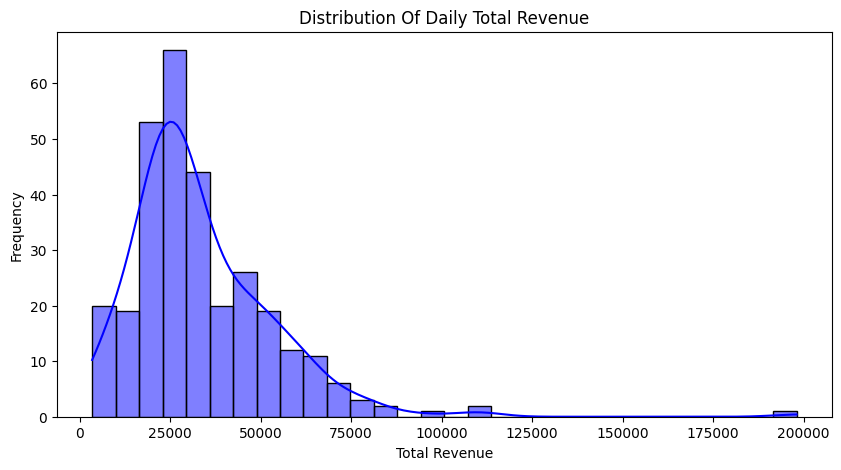

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(daily_sales['Total_Revenue'],kde=True,bins=30,color='blue')
plt.title('Distribution Of Daily Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.show()

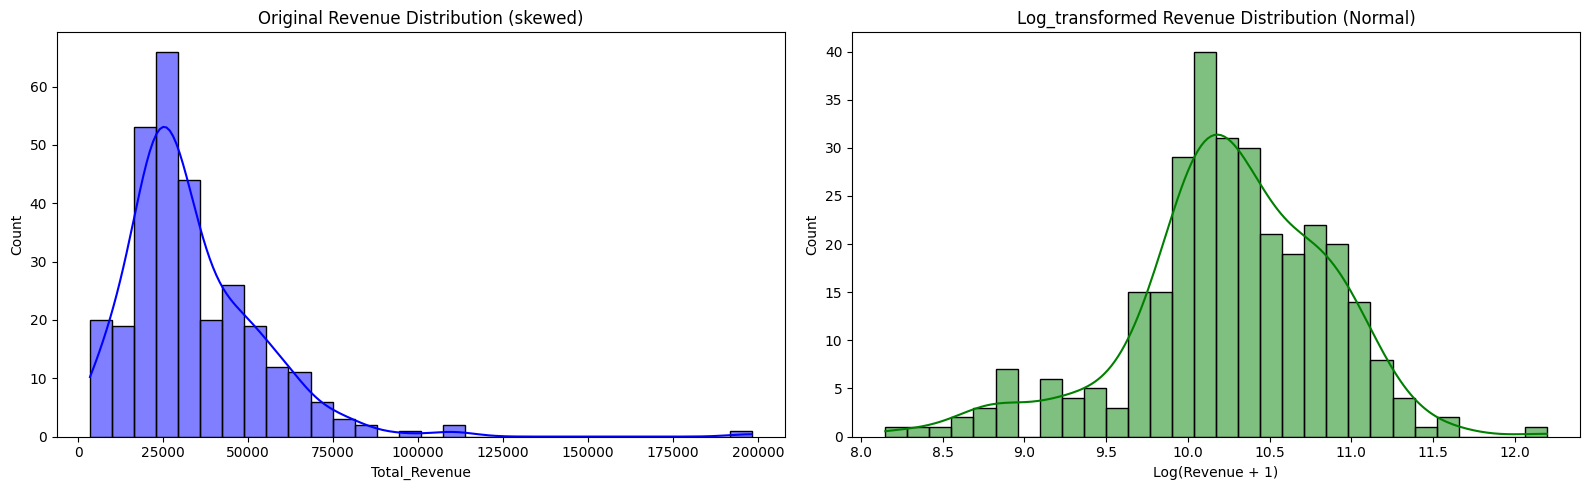

In [30]:
fig, axes = plt.subplots(1,2, figsize=(16,5))

#1. plot the original distribution
sns.histplot(daily_sales['Total_Revenue'],kde=True,bins=30,color='blue',ax=axes[0])
axes[0].set_title('Original Revenue Distribution (skewed)')
axes[0].set_xlabel('Total_Revenue')

#2. Apply log transformation and plot
daily_sales['Log_Revenue']=np.log1p(daily_sales['Total_Revenue'])
sns.histplot(daily_sales['Log_Revenue'],kde=True,bins=30,color='green',ax=axes[1])
axes[1].set_title('Log_transformed Revenue Distribution (Normal)')
axes[1].set_xlabel('Log(Revenue + 1)')

plt.tight_layout()
plt.show()

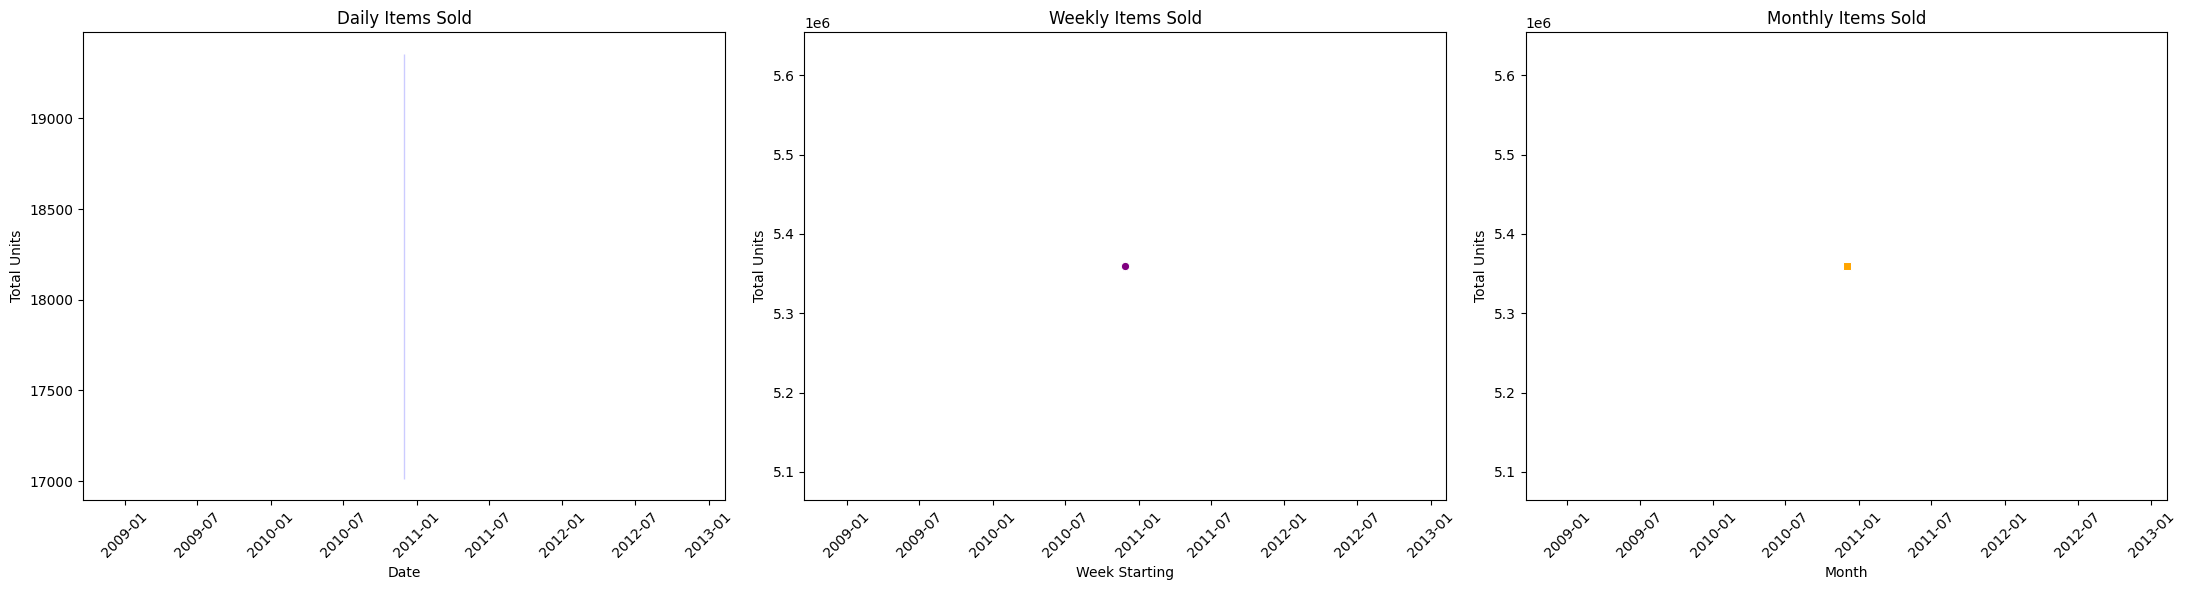

In [31]:

# 1. Ensure Date column is a datetime object
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

# 2. Extract periods smoothly
daily_sales['Weekly'] = daily_sales['Date'].dt.to_period('W').dt.to_timestamp()
daily_sales['Monthly'] = daily_sales['Date'].dt.to_period('M').dt.to_timestamp()

# 3. Aggregate explicitly using 'Total_Quantity_Sold'
weekly_qty = daily_sales.groupby('Weekly')['Total_Quantity_sold'].sum().reset_index()
monthly_qty = daily_sales.groupby('Monthly')['Total_Quantity_sold'].sum().reset_index()

# 4. Plot the 3 charts side-by-side
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Chart 1: Daily
sns.lineplot(data=daily_sales, x='Date', y='Total_Quantity_sold', color='blue', alpha=0.6, ax=axes[0])
axes[0].set_title('Daily Items Sold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Units')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Weekly
sns.lineplot(data=weekly_qty, x='Weekly', y='Total_Quantity_sold', marker='o', color='purple', ax=axes[1])
axes[1].set_title('Weekly Items Sold')
axes[1].set_xlabel('Week Starting')
axes[1].set_ylabel('Total Units')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Monthly
sns.lineplot(data=monthly_qty, x='Monthly', y='Total_Quantity_sold', marker='s', color='orange', linewidth=2.5, ax=axes[2])
axes[2].set_title('Monthly Items Sold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Total Units')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
print('Date column date type:',daily_sales['Date'].dtype)
print('Earliest date in data:',daily_sales['Date'].min())
print('latest date in data:',daily_sales['Date'].max())
print(daily_sales.head())

Date column date type: datetime64[ns]
Earliest date in data: 2010-12-01 00:00:00
latest date in data: 2010-12-01 00:00:00
        Date  Total_Revenue  Total_Quantity_sold  Week_Number  Log_Revenue  \
0 2010-12-01       57676.33                26910          0.0    10.962619   
1 2010-12-01       47730.38                31328          0.0    10.773344   
2 2010-12-01       44833.98                16177          0.0    10.710744   
3 2010-12-01       31318.99                16371          0.0    10.352012   
4 2010-12-01       51973.43                21770          0.0    10.858507   

      Weekly    Monthly  
0 2010-11-29 2010-12-01  
1 2010-11-29 2010-12-01  
2 2010-11-29 2010-12-01  
3 2010-11-29 2010-12-01  
4 2010-11-29 2010-12-01  
